<img src="LOGO ITQ (2).png" width="200">

# Ejercicio Deber Análisis de datos clínicos para la detección de enfermedades cardíacas
### **Nombre:** Mónica Guano
#### **Fecha:** 10/05/2026

# Práctica Académica
### Normalización y Estandarización de Datos en Inteligencia Artificial
## Análisis y aplicación de técnicas de normalización y estandarización en conjunto de datos para modelos de aprendizaje automático
### Enunciado
En la actualidad, las enfermedades cardiovasculares representan una de las principales causas de mortalidad a nivel mundial, lo que ha impulsado el uso de técnicas de análisis de datos e inteligencia artificial para apoyar en su detección temprana.<br>

Un centro médico especializado ha recopilado un conjunto de datos clínicos de pacientes, el cual incluye variables como edad, presión arterial, niveles de colesterol, frecuencia cardíaca máxima y otros indicadores relevantes para la salud cardiovascular. Sin embargo, durante el análisis preliminar, se ha identificado que los datos presentan diferencias significativas en sus escalas y rangos, lo que podría afectar negativamente el desempeño de los modelos predictivos.<br>

Como parte del equipo de analistas de datos, se le ha asignado la tarea de realizar un proceso de preprocesamiento de los datos, específicamente aplicando técnicas de normalización y estandarización, con el objetivo de preparar la información para su uso en modelos de aprendizaje automático orientados a la clasificación de pacientes con riesgo de enfermedad cardíaca.<br>
El propósito de esta actividad es comprender cómo las diferencias en la escala de los datos pueden influir en los resultados y cómo las técnicas de escalado permiten mejorar la calidad del análisis y la precisión de los modelos.<br>
### Objetivo General
Aplicar técnicas de normalización y estandarización a un conjunto de datos clínicos relacionados con enfermedades cardíacas, con el fin de analizar su impacto en la preparación de datos y en el rendimiento de modelos de aprendizaje automático.<br>
### Objetivos especificos
* Identificar diferencias de escala entre variables numércias.
* Aplicar técnicas de normalización (Min-Max)
* Aplicar técnicas de estandarización (Z-score)
* Analizar la importancia del preprocesaminto en modelos de IA
### Antecedentes /Fundamentación teórica
En el contexto del aprendizaje automático, los algoritmos suelen verse afectados por la escala de los datos. Variables con valores grandes pueden dominar el comportamiento del modelo, generando sesgos y resultados pocos conficables.<br>
Para mitigar este problema, se emplea técnicas como:
* **Normalización**: transforma los datos a un rango especifico (generalmente[0,1])
* **Estandarización**: ajusta los datos para que tengan mdia 0 y desviación estandar 1.
Estas técnicas son fundamentales en algoritmos como:
* KNN
* Regresión logística
* Redes neuronales
### Resultado esperado
El estudiante será capaz de reconocer la importancia del escalado de datos en contextos reales de salud, comprendiendo que un adecuado preprocesamiento es fundamental para el desarrollo de modelos predictivos confiables en inteligencia artificial.
### Conjunto de datos  utilizar
DataSet 1: <a href="https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset">Conjunto de datos de enfermedades cardiacas</a>

In [1]:
#Importacion de librerias 
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [2]:
#Configuramos el entorno de descarga
import os
os.environ['KAGGLE_CONFIG_DIR']="C:/Users/monig/.kaggle"

In [3]:
#Creamos la carpeta dataset
os.makedirs("dataset", exist_ok=True)

In [4]:
#Descargamos el dataset
!kaggle datasets download -d johnsmith88/heart-disease-dataset

Dataset URL: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
License(s): unknown
heart-disease-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
#Descompriminos el archivo 
with zipfile.ZipFile("heart-disease-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [6]:
#Cargamos el conjunto de datos
df = pd.read_csv("dataset/heart.csv")

In [7]:
#mostramos el conjunto de datos"
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


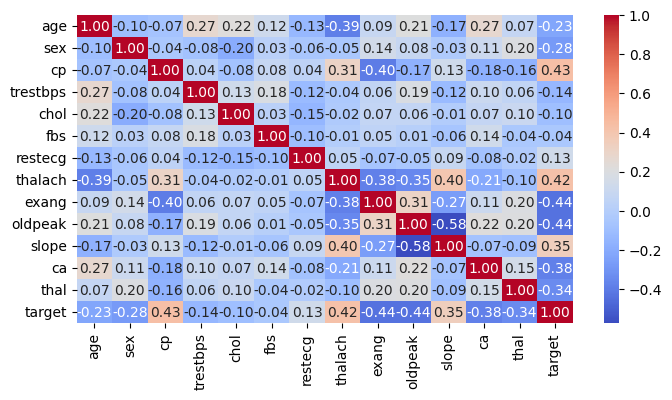

In [8]:
# ¿Cómo identificar la variable menos representativa en el dataset?
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

#### Eliminamos columnas innecesarias en la limpieza de datos: 
**fbs (Fasting Blood Sugar / Azúcar en sangre en ayunas)**

**¿Por qué eliminarla?**
* **Baja correlación:** En casi todos los análisis estadísticos realizados sobre este dataset (como las matrices de correlación de Pearson), fbs suele mostrar una correlación cercana a 0 con la variable objetivo (target). Esto significa que, por sí sola, no ayuda mucho al modelo a distinguir quién tiene una enfermedad cardíaca y quién no.

* **Redundancia:** Aunque la diabetes es un factor de riesgo para el corazón, el impacto de los niveles de azúcar ya suele estar reflejado indirectamente en otros indicadores más determinantes presentes en el dataset, como el colesterol (chol) o la presión arterial (trestbps).

In [9]:
#Eliminamos columnas innecesarias en la limpieza de datos:
if 'fbs' in df.columns:
    df=df.drop(columns=["fbs"])


In [10]:
#Mostramos los detalles de nuesto dataset
df.info()
#Verificamos si tenemos datos nulos si lo tenemos lo sumamos 
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   restecg   1025 non-null   int64  
 6   thalach   1025 non-null   int64  
 7   exang     1025 non-null   int64  
 8   oldpeak   1025 non-null   float64
 9   slope     1025 non-null   int64  
 10  ca        1025 non-null   int64  
 11  thal      1025 non-null   int64  
 12  target    1025 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 104.2 KB


age         0
sex         0
cp          0
trestbps    0
chol        0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [11]:
#Separamos los datos de entrada con nuestra variable objetivo 
X=df.drop(columns=['target'])
y=df['target']

In [12]:
#Exploramos o generamos un analis exploratorio del conjunto de datos
X.describe()

,age,sex,cp,trestbps,chol,restecg,thalach,exang,oldpeak,slope,ca,thal
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000


#### Conclusión:

La tabla muestra tres puntos críticas:
* **Diferencia de escalas:** La columna **age** tiene valores entre 29 y 77, mientras que **chol (colesterol)** puede llegar hasta 564 y **oldpeak** tiene valores decimales pequeños (como 0.1 o 2.0).
* **Variables Binarias vs. Continuas:** La columna **sex** tiene valores 0 y 1, mientras que **thalach (ritmo cardíaco)** se mueve en rangos de 70 a 202.
* Presencia de Outliers

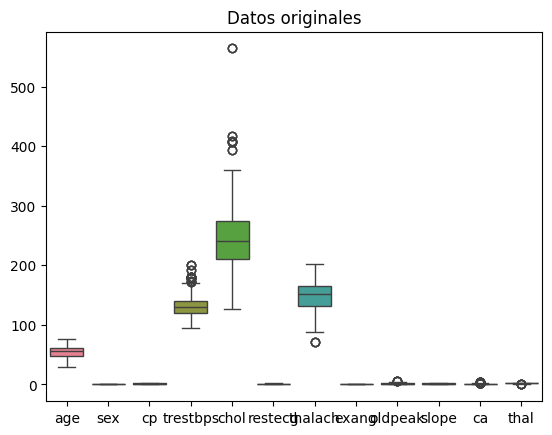

In [13]:
#dibujamos los datos originales 
sns.boxplot(data=X)
#Ponemos un titulo a la imagen 
plt.title("Datos originales")
plt.show()

Si el valor máximo de una columna está muy alejado de la media (mean), como es el caso del colesterol, refleja valores atípicos que pueden sesgar las predicciones.

In [14]:
#Normalizamos el conjunto de datos 
normalizer = preprocessing.MinMaxScaler()
X_norm=normalizer.fit_transform(X)
X_norm = pd.DataFrame(X_norm, columns=X.columns)
X_norm.head()

,age,sex,cp,trestbps,chol,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.479167,1.0,0.0,0.292453,0.196347,0.5,0.740458,0.0,0.161290,1.0,0.50,1.000000
1,0.500000,1.0,0.0,0.433962,0.175799,0.0,0.641221,1.0,0.500000,0.0,0.00,1.000000
2,0.854167,1.0,0.0,0.481132,0.109589,0.5,0.412214,1.0,0.419355,0.0,0.00,1.000000
3,0.666667,1.0,0.0,0.509434,0.175799,0.5,0.687023,0.0,0.000000,1.0,0.25,1.000000
4,0.687500,0.0,0.0,0.415094,0.383562,0.5,0.267176,0.0,0.306452,0.5,0.75,0.666667


In [15]:
X_norm.describe()

,age,sex,cp,trestbps,chol,restecg,thalach,exang,oldpeak,slope,ca,thal
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,0.529878,0.695610,0.314146,0.354827,0.273973,0.264878,0.596291,0.336585,0.172825,0.692683,0.188537,0.774634
std,0.189006,0.460373,0.343214,0.165252,0.117791,0.263939,0.175616,0.472772,0.189525,0.308878,0.257699,0.206887
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.395833,0.000000,0.000000,0.245283,0.194064,0.000000,0.465649,0.000000,0.000000,0.500000,0.000000,0.666667
50%,0.562500,1.000000,0.333333,0.339623,0.260274,0.500000,0.618321,0.000000,0.129032,0.500000,0.000000,0.666667
75%,0.666667,1.000000,0.666667,0.433962,0.340183,0.500000,0.725191,1.000000,0.290323,1.000000,0.250000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [16]:
#Estandarización 
standarizer = preprocessing.StandardScaler()
#Estandarizamos los datos
X_std=standarizer.fit_transform(X)
X_std= pd.DataFrame(X_std, columns=X.columns)
X_std.head()

,age,sex,cp,trestbps,chol,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.268437,0.661504,-0.915755,-0.377636,-0.659332,0.891255,0.821321,-0.712287,-0.060888,0.995433,1.209221,1.089852
1,-0.158157,0.661504,-0.915755,0.479107,-0.833861,-1.004049,0.255968,1.403928,1.727137,-2.243675,-0.731971,1.089852
2,1.716595,0.661504,-0.915755,0.764688,-1.396233,0.891255,-1.048692,1.403928,1.301417,-2.243675,-0.731971,1.089852
3,0.724079,0.661504,-0.915755,0.936037,-0.833861,0.891255,0.516900,-0.712287,-0.912329,0.995433,0.238625,1.089852
4,0.834359,-1.511706,-0.915755,0.364875,0.930822,0.891255,-1.874977,-0.712287,0.705408,-0.624121,2.179817,-0.522122


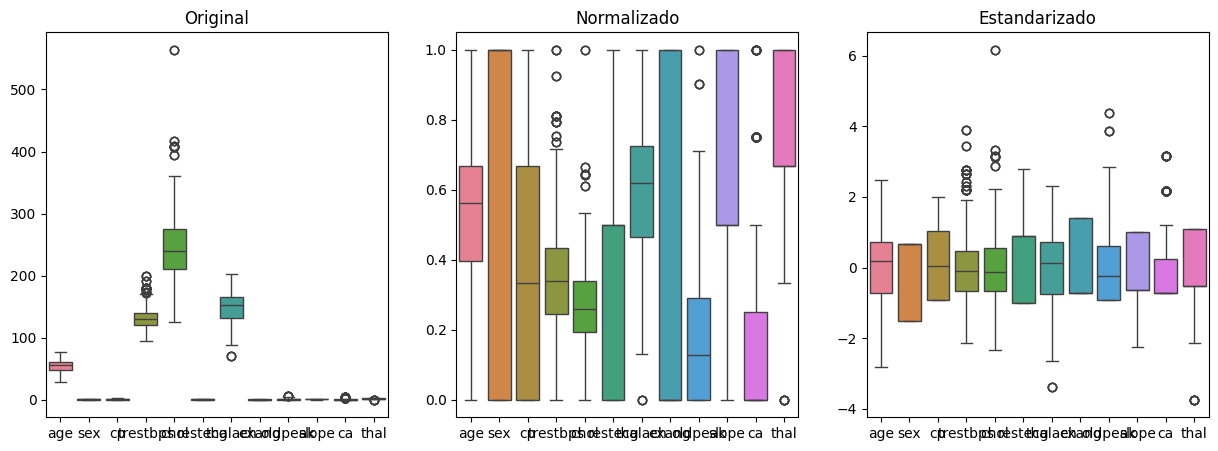

In [17]:
#Comporación visual
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(data=X)
plt.title("Original")

plt.subplot(1,3,2)
sns.boxplot(data=X_norm)
plt.title("Normalizado")

plt.subplot(1,3,3)
sns.boxplot(data=X_std)
plt.title("Estandarizado")

plt.show()

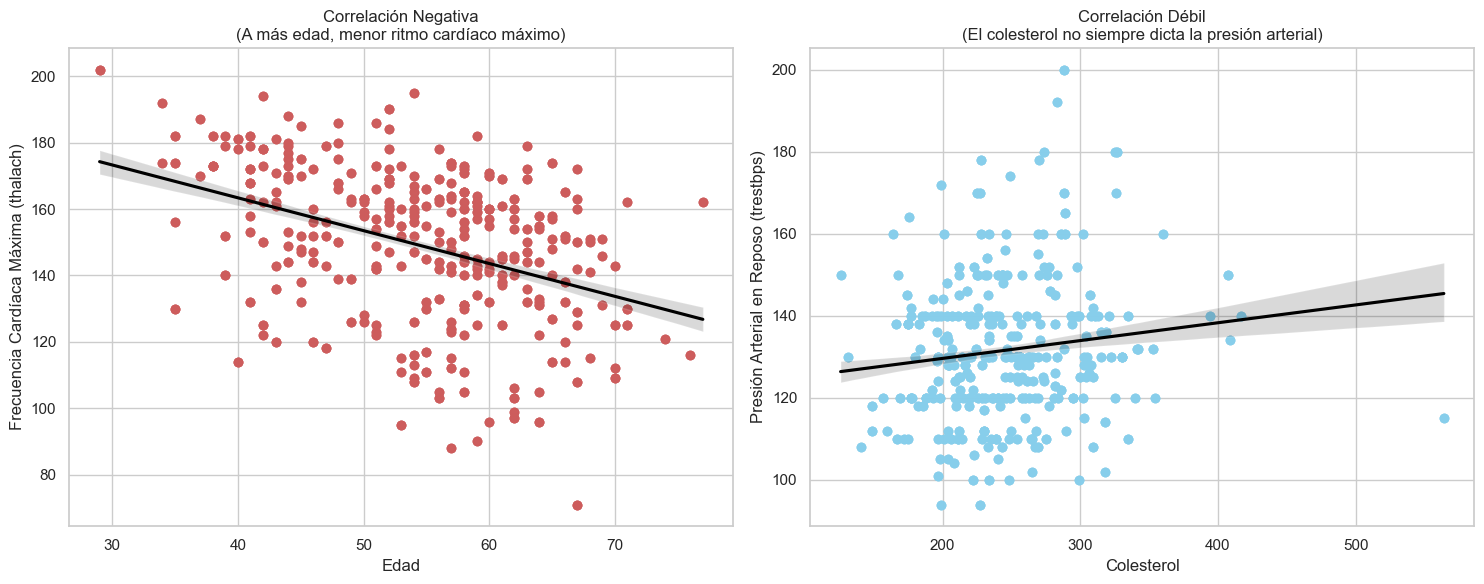

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfica 1: Correlación Negativa (Edad vs Ritmo Cardíaco)
sns.regplot(ax=axes[0], x='age', y='thalach', data=df, color='indianred', line_kws={"color": "black"})
axes[0].set_title('Correlación Negativa\n(A más edad, menor ritmo cardíaco máximo)')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia Cardíaca Máxima (thalach)')

# Gráfica 2: Correlación Nula o Débil (Colesterol vs Presión Arterial)
sns.regplot(ax=axes[1], x='chol', y='trestbps', data=df, color='skyblue', line_kws={"color": "black"})
axes[1].set_title('Correlación Débil\n(El colesterol no siempre dicta la presión arterial)')
axes[1].set_xlabel('Colesterol')
axes[1].set_ylabel('Presión Arterial en Reposo (trestbps)')

plt.tight_layout()
plt.show()